## Library Imports

Import the Python libraries required for data analysis and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

Load all Olist datasets into pandas DataFrames to prepare the data for further validation and analysis.

In [2]:
cust = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
prod = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
pay = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
geo = pd.read_csv('olist_geolocation_dataset.csv')
trans = pd.read_csv('product_category_name_translation.csv')

# MODULE 1 — RFM Analysis

Q1 — RFM Calculation
    → Required data selection
    → Merge
    → Date/reference-date preparation
    → Recency calculation
    → Frequency calculation
    → Monetary calculation
    → RFM table

In [60]:
# Keep only delivered orders
rfm_orders = orders[
    orders['order_status'] == 'delivered'
].copy()

# Calculate total order value
order_revenue = (
    items.groupby('order_id')['price']
    .sum()
    .rename('order_value')
    .reset_index()
)

# Merge order value with delivered orders
rfm_orders = rfm_orders.merge(
    order_revenue,
    on='order_id',
    how='left'
)

# Convert purchase timestamp to datetime
rfm_orders['order_purchase_timestamp'] = pd.to_datetime(
    rfm_orders['order_purchase_timestamp']
)

# Set reference date for recency calculation
reference_date = (
    rfm_orders['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)

# Add unique customer identifier
rfm_orders = rfm_orders.merge(
    cust[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# Calculate RFM metrics for each customer
rfm = (
    rfm_orders.groupby('customer_unique_id')
    .agg(
        Recency=(
            'order_purchase_timestamp',
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=('order_id', 'nunique'),
        Monetary=('order_value', 'sum')
    )
    .reset_index()
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


## Q1.2 — RFM Scoring

Assign scores to Recency, Frequency, and Monetary values to measure customer engagement and purchasing behavior.

In [65]:
# Score Recency from 1 to 5
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

# Score Frequency based on purchase frequency
conditions = [
    rfm['Frequency'] == 1,
    rfm['Frequency'] == 2,
    rfm['Frequency'] == 3,
    rfm['Frequency'].between(4, 5),
    rfm['Frequency'] >= 6
]

rfm['F_score'] = np.select(
    conditions,
    [1, 2, 3, 4, 5]
)

# Score Monetary based on customer spending
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Combine RFM scores
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,215


## Q1.3 — Customer Segmentation

Group customers into meaningful RFM segments and compare their customer share and revenue contribution.

In [68]:
# Create the combined RFM score
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

# Assign customers to RFM segments
rfm['Customer_Segment'] = np.select(
    [
        (rfm['R_score'].astype(int) >= 4) &
        (rfm['F_score'].astype(int) >= 4) &
        (rfm['M_score'].astype(int) >= 4),

        (rfm['R_score'].astype(int) >= 3) &
        (rfm['F_score'].astype(int) >= 3) &
        (rfm['M_score'].astype(int) >= 3),

        (rfm['R_score'].astype(int) >= 4) &
        (rfm['F_score'].astype(int) <= 2),

        (rfm['R_score'].astype(int) <= 2) &
        (rfm['F_score'].astype(int) >= 3) &
        (rfm['M_score'].astype(int) >= 3),

        (rfm['R_score'].astype(int) <= 2) &
        (rfm['F_score'].astype(int) <= 2)
    ],
    [
        'Champions',
        'Loyal Customers',
        'Potential Loyalists',
        'At Risk',
        'Lost Customers'
    ],
    default='General / Hibernating'
)

# Summarize customers and revenue by segment
segment_summary = (
    rfm.groupby('Customer_Segment')
    .agg(
        Customer_Count=('customer_unique_id', 'count'),
        Revenue=('Monetary', 'sum')
    )
    .reset_index()
)

# Calculate customer and revenue contribution
segment_summary['Customer_%'] = (
    segment_summary['Customer_Count']
    / segment_summary['Customer_Count'].sum()
    * 100
)

segment_summary['Revenue_%'] = (
    segment_summary['Revenue']
    / segment_summary['Revenue'].sum()
    * 100
)

segment_summary

,Customer_Segment,Customer_Count,Revenue,Customer_%,Revenue_%
0,At Risk,62,23950.42,0.066411,0.181148
1,Champions,33,23983.70,0.035348,0.181399
2,General / Hibernating,18681,2492472.45,20.010069,18.851664
3,Lost Customers,37147,5279536.48,39.789841,39.931454
4,Loyal Customers,124,48777.16,0.132822,0.368923
5,Potential Loyalists,37311,5352777.90,39.965509,40.485411


### Revenue by Customer Segment

Visualize the revenue contribution of each customer segment to understand which segments generate the most revenue.

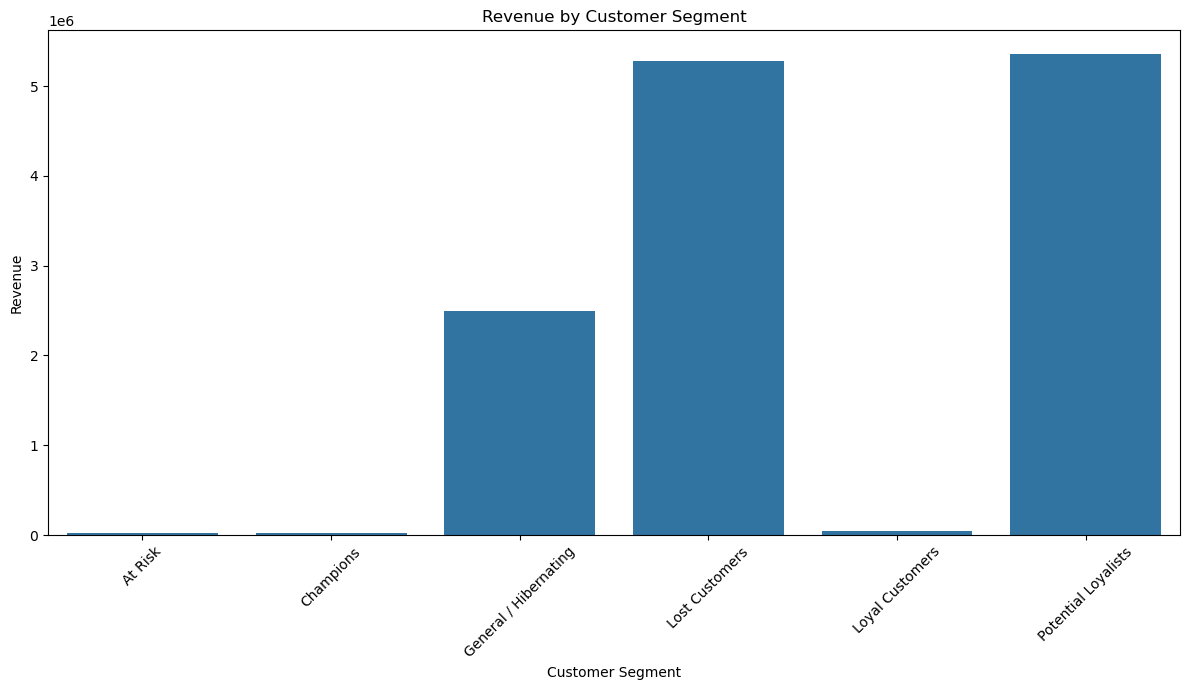

In [22]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=segment_summary,
    x='Customer_Segment',
    y='Revenue'
)

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Distribution by Segment

Visualize the customer distribution across RFM segments to understand the size of each customer group.

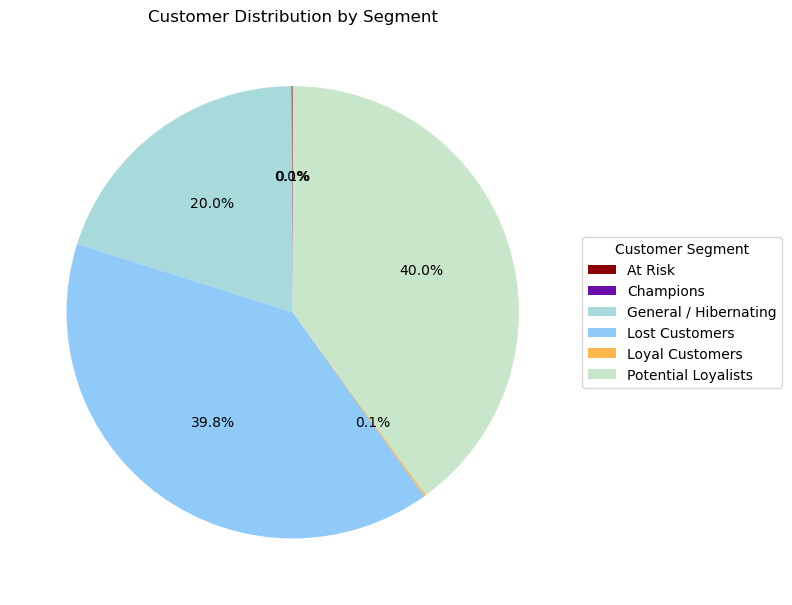

In [23]:
plt.figure(figsize=(8, 8))

colors = [
    '#8B0000',  # At Risk - 0.07% - deep red
    '#6A0DAD',  # Champions - 0.04% - deep purple
    '#A8DADC',  # General / Hibernating - 20.01% - light cyan
    '#90CAF9',  # Lost Customers - 39.79% - light blue
    '#FFB74D',  # Loyal Customers - 0.13% - deep-ish orange
    '#C8E6C9'   # Potential Loyalists - 39.97% - light green
]

plt.pie(
    segment_summary['Customer_Count'],
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    segment_summary['Customer_Segment'],
    title='Customer Segment',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Customer Distribution by Segment')
plt.tight_layout()
plt.show()

# MODULE 2 — Cohort Analysis

## Q2.1 — Customer Acquisition Cohort

Identify each customer's first purchase month and assign a month index to track subsequent purchasing activity.

In [71]:
# Convert order date to datetime and create order month
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_month'] = (
    orders['order_purchase_timestamp'].dt.to_period('M')
)

# Add unique customer ID
cohort = orders.merge(
    cust[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# Find each customer's first purchase month
cust_cohort = (
    cohort.groupby('customer_unique_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

# Add cohort month to each order
cohort = cohort.merge(
    cust_cohort,
    on='customer_unique_id',
    how='left'
)

# Keep required columns and remove duplicates
cohort = cohort[
    ['customer_unique_id', 'cohort_month', 'order_month']
].drop_duplicates()

# Calculate months since first purchase
cohort['month_index'] = (
    (cohort['order_month'].dt.year - cohort['cohort_month'].dt.year) * 12
    + (cohort['order_month'].dt.month - cohort['cohort_month'].dt.month)
)

cohort.head()

,customer_unique_id,cohort_month,order_month,month_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0


## Q2.2 — Customer Retention Analysis

Calculate the number of active customers across cohorts and convert the results into retention percentages relative to the first purchase month.

In [73]:
# Count active customers by cohort and month
retention = (
    cohort
    .groupby(['cohort_month', 'month_index'])['customer_unique_id']
    .nunique()
    .reset_index(name='customers')
)

# Create the retention matrix
retention_matrix = retention.pivot(
    index='cohort_month',
    columns='month_index',
    values='customers'
)

# Calculate retention percentage from Month 0
retention_pct = (
    retention_matrix
    .div(retention_matrix[0], axis=0)
    * 100
)

retention_pct

month_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.311526,NaN,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,0.623053,0.623053
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.392670,0.261780,0.130890,0.392670,0.130890,0.523560,0.130890,0.130890,NaN,0.392670,0.130890,0.785340,0.392670,0.130890,0.130890,0.261780,0.392670,0.130890,NaN
2017-02,100.0,0.228311,0.285388,0.114155,0.399543,0.114155,0.228311,0.171233,0.171233,0.228311,0.114155,0.285388,0.171233,0.171233,0.114155,0.057078,0.057078,0.228311,NaN,NaN
2017-03,100.0,0.493171,0.379363,0.379363,0.341426,0.151745,0.151745,0.303490,0.341426,0.075873,0.379363,0.151745,0.227618,0.113809,0.151745,0.227618,0.075873,0.151745,NaN,NaN
2017-04,100.0,0.595238,0.212585,0.170068,0.340136,0.255102,0.340136,0.297619,0.297619,0.170068,0.255102,0.085034,0.085034,0.042517,0.085034,0.085034,0.212585,NaN,NaN,NaN
2017-05,100.0,0.500556,0.500556,0.389321,0.305895,0.333704,0.417130,0.166852,0.250278,0.305895,0.250278,0.333704,0.250278,0.027809,0.194661,0.250278,NaN,NaN,NaN,NaN
2017-06,100.0,0.477859,0.350430,0.414145,0.254858,0.382287,0.382287,0.223001,0.127429,0.223001,0.318573,0.350430,0.159286,0.127429,0.191144,NaN,NaN,NaN,NaN,NaN


### Customer Retention Heatmap

Visualize retention rates across customer cohorts to identify how customer activity changes over time.

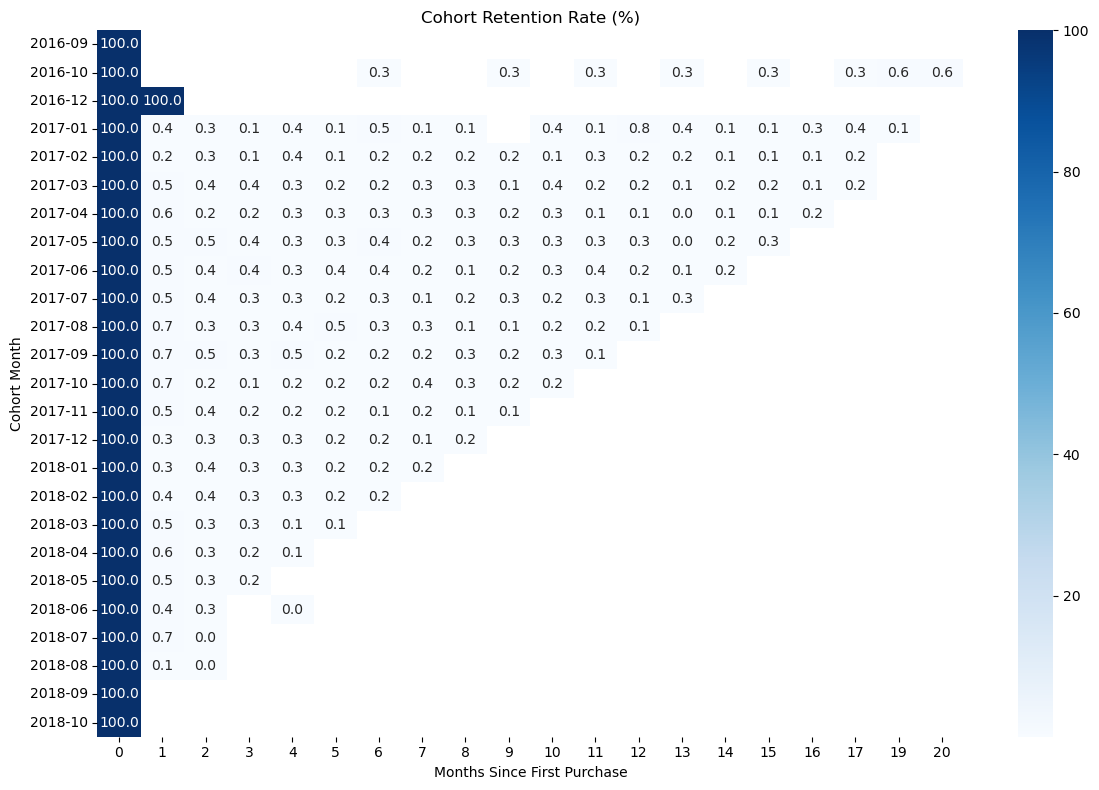

In [74]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Cohort Retention Rate (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.tight_layout()
plt.show()

## Q2.3 — Cohort Average Order Value Progression

Calculate the average order value for each customer cohort across months since their first purchase.

In [76]:
# Calculate total order value
order_revenue = (
    items.groupby('order_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'order_value'})
)

# Prepare cohort data
cohort_aov = orders.merge(
    cust[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

cohort_aov = cohort_aov[
    ['order_id', 'customer_unique_id', 'order_month']
].copy()

# Add cohort month
cohort_aov = cohort_aov.merge(
    cust_cohort,
    on='customer_unique_id',
    how='left'
)

cohort_aov.head()

# Add order value
cohort_aov = cohort_aov.merge(
    order_revenue,
    on='order_id',
    how='left'
)

cohort_aov.head()

# Calculate months since first purchase
cohort_aov['month_index'] = (
    (cohort_aov['order_month'].dt.year - cohort_aov['cohort_month'].dt.year) * 12
    + (cohort_aov['order_month'].dt.month - cohort_aov['cohort_month'].dt.month)
)

# Calculate average order value by cohort and month
aov = (
    cohort_aov
    .groupby(['cohort_month', 'month_index'])['order_value']
    .mean()
    .reset_index(name='avg_order_value')
)

aov.head()

,cohort_month,month_index,avg_order_value
0,2016-09,0,89.120000
1,2016-10,0,160.739156
2,2016-10,6,99.990000
3,2016-10,9,339.000000
4,2016-10,11,49.000000


### Cohort Average Order Value Progression

Visualize the average order value across cohorts to understand how customer spending changes over time.

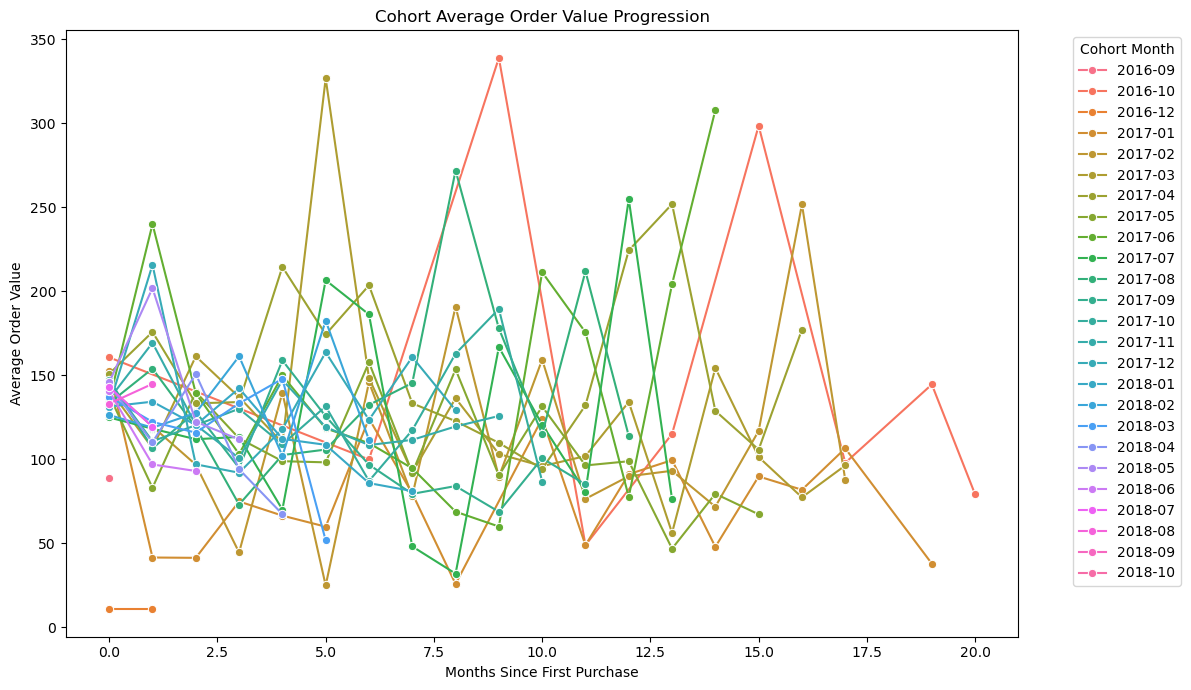

In [42]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=aov,
    x='month_index',
    y='avg_order_value',
    hue='cohort_month',
    marker='o'
)

plt.title('Cohort Average Order Value Progression')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Order Value')
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Selected Cohorts for Visualization

Select a smaller set of cohorts to keep the line chart clear and readable while comparing average order value progression over time.

In [43]:
selected_cohorts = [
    '2017-01', '2017-04', '2017-07',
    '2017-10', '2018-01', '2018-04', '2018-07'
]

aov_chart = aov[
    aov['cohort_month'].astype(str).isin(selected_cohorts)
].copy()


### Average Order Value Progression for Selected Cohorts

Visualize the average order value progression for selected cohorts to make cohort-level spending patterns easier to compare.

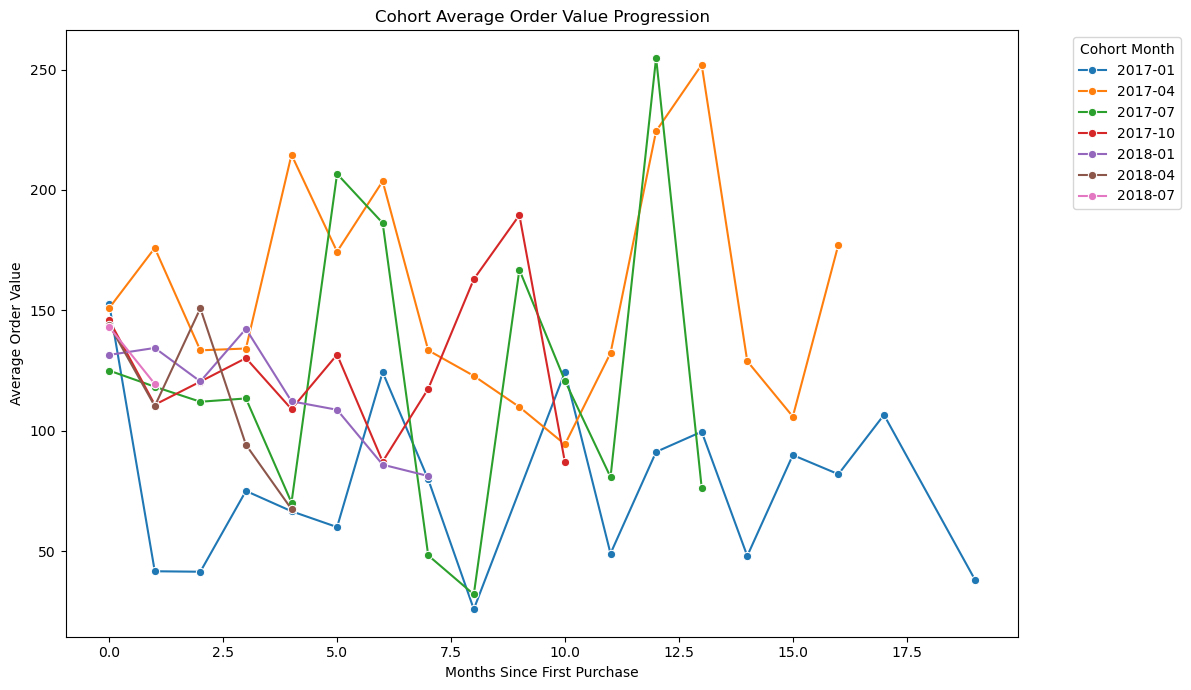

In [77]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=aov_chart,
    x='month_index',
    y='avg_order_value',
    hue='cohort_month',
    marker='o'
)

plt.title('Cohort Average Order Value Progression')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Order Value')
plt.legend(
    title='Cohort Month',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# MODULE 3 — Logistics & SLA Deep-Dive

## Q3.1 — Delivery Gap Calculation & IQR Outliers

Calculate the delivery gap against the estimated delivery date and identify potential outliers using the IQR method.

In [78]:
# Q3.1 — Delivery Gap and IQR

# Step 1: Select required columns
delivery_df = orders[
    [
        'order_id',
        'order_estimated_delivery_date',
        'order_delivered_customer_date'
    ]
].copy()


# Step 2: Convert date columns to datetime
delivery_df['order_estimated_delivery_date'] = pd.to_datetime(
    delivery_df['order_estimated_delivery_date']
)

delivery_df['order_delivered_customer_date'] = pd.to_datetime(
    delivery_df['order_delivered_customer_date']
)


# Step 3: Remove orders with missing actual delivery date
delivery_df = delivery_df.dropna(
    subset=['order_delivered_customer_date']
)


# Step 4: Calculate delivery gap in days
delivery_df['delivery_gap_days'] = (
    delivery_df['order_delivered_customer_date']
    - delivery_df['order_estimated_delivery_date']
).dt.days


# Step 5: Basic statistics
delivery_stats = delivery_df['delivery_gap_days'].describe()

print(delivery_stats)


# Step 6: Calculate Q1, Q3 and IQR
Q1 = delivery_df['delivery_gap_days'].quantile(0.25)
Q3 = delivery_df['delivery_gap_days'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


# Step 7: Calculate outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


# Step 8: Identify outliers
outliers = delivery_df[
    (delivery_df['delivery_gap_days'] < lower_bound) |
    (delivery_df['delivery_gap_days'] > upper_bound)
].copy()

print("Number of outliers:", len(outliers))


count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_gap_days, dtype: float64
Q1: -17.0
Q3: -7.0
IQR: 10.0
Lower Bound: -32.0
Upper Bound: 8.0
Number of outliers: 4301


### Delivery Gap Distribution

Visualize the distribution of delivery gaps to understand the spread of delivery performance and identify potential outliers.

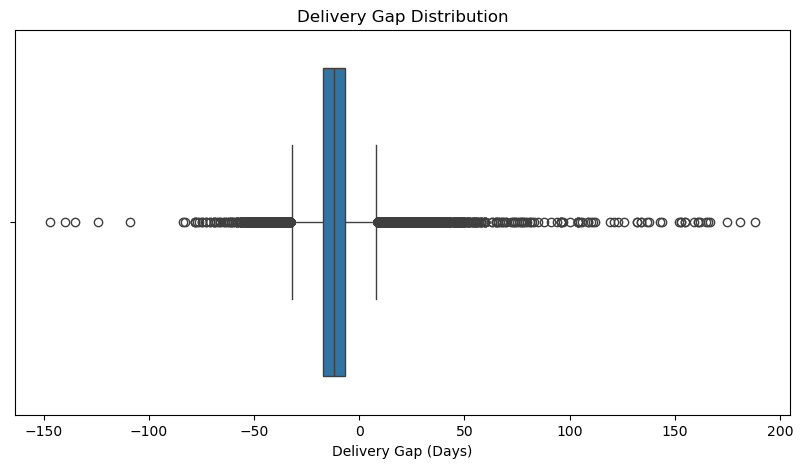

In [81]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=delivery_df['delivery_gap_days']
)

plt.title('Delivery Gap Distribution')
plt.xlabel('Delivery Gap (Days)')

plt.show()

## Q3.1 — State-wise Average Delivery Gap

Calculate the average delivery gap for each customer state to compare delivery performance across different regions.

In [83]:
# Select required columns from orders
state_delivery_df = orders[
    [
        'order_id',
        'customer_id',
        'order_estimated_delivery_date',
        'order_delivered_customer_date'
    ]
].copy()

# Select customer state
customer_state_df = cust[
    ['customer_id', 'customer_state']
].copy()

# Merge orders with customer state
state_delivery_df = state_delivery_df.merge(
    customer_state_df,
    on='customer_id',
    how='left'
)

# Convert delivery dates to datetime
state_delivery_df['order_estimated_delivery_date'] = pd.to_datetime(
    state_delivery_df['order_estimated_delivery_date']
)

state_delivery_df['order_delivered_customer_date'] = pd.to_datetime(
    state_delivery_df['order_delivered_customer_date']
)

# Remove orders with missing actual delivery date
state_delivery_df = state_delivery_df.dropna(
    subset=['order_delivered_customer_date']
)

# Calculate delivery gap
state_delivery_df['delivery_gap_days'] = (
    state_delivery_df['order_delivered_customer_date']
    - state_delivery_df['order_estimated_delivery_date']
).dt.days

# Calculate average delivery gap by state
state_delay = (
    state_delivery_df
    .groupby('customer_state')['delivery_gap_days']
    .mean()
)

# Sort from highest to lowest average delay
state_delay = state_delay.sort_values(
    ascending=False
)

state_delay

customer_state
AL    -8.707809
MA    -9.571827
SE   -10.020896
ES   -10.496241
BA   -10.794533
CE   -10.804535
MS   -11.052782
SP   -11.076380
PI   -11.306723
SC   -11.508317
RJ   -11.766858
DF   -12.048077
TO   -12.131387
GO   -12.185488
MG   -13.240775
PB   -13.261122
PE   -13.293785
PR   -13.314239
RN   -13.649789
RS   -13.910367
PA   -14.066596
MT   -14.363431
RR   -17.292683
AM   -19.565517
AP   -19.686567
RO   -20.102881
AC   -20.725000
Name: delivery_gap_days, dtype: float64

## Q3.2 — State-wise Average Delivery Gap

Calculate the average delivery gap for each customer state to compare delivery performance across different regions.

In [87]:
# Step 1: Select required columns from orders
state_delivery_df = orders[
    [
        'order_id',
        'customer_id',
        'order_estimated_delivery_date',
        'order_delivered_customer_date'
    ]
].copy()


# Step 2: Select customer state information
customer_state_df = cust[
    [
        'customer_id',
        'customer_state'
    ]
].copy()


# Step 3: Merge orders with customer state
state_delivery_df = state_delivery_df.merge(
    customer_state_df,
    on='customer_id',
    how='left'
)


# Step 4: Convert delivery dates to datetime
state_delivery_df['order_estimated_delivery_date'] = pd.to_datetime(
    state_delivery_df['order_estimated_delivery_date']
)

state_delivery_df['order_delivered_customer_date'] = pd.to_datetime(
    state_delivery_df['order_delivered_customer_date']
)


# Step 5: Remove orders with missing actual delivery date
state_delivery_df = state_delivery_df.dropna(
    subset=['order_delivered_customer_date']
)


# Step 6: Calculate delivery gap
state_delivery_df['delivery_gap_days'] = (
    state_delivery_df['order_delivered_customer_date']
    - state_delivery_df['order_estimated_delivery_date']
).dt.days


# Step 7: Calculate average delivery gap by state
state_delay = (
    state_delivery_df
    .groupby('customer_state')['delivery_gap_days']
    .mean()
)


# Step 8: Sort from highest to lowest average delay
state_delay = state_delay.sort_values(
    ascending=False
)


# Step 9: Display results
print(state_delay)




customer_state
AL    -8.707809
MA    -9.571827
SE   -10.020896
ES   -10.496241
BA   -10.794533
CE   -10.804535
MS   -11.052782
SP   -11.076380
PI   -11.306723
SC   -11.508317
RJ   -11.766858
DF   -12.048077
TO   -12.131387
GO   -12.185488
MG   -13.240775
PB   -13.261122
PE   -13.293785
PR   -13.314239
RN   -13.649789
RS   -13.910367
PA   -14.066596
MT   -14.363431
RR   -17.292683
AM   -19.565517
AP   -19.686567
RO   -20.102881
AC   -20.725000
Name: delivery_gap_days, dtype: float64


### Average Delivery Gap by State

Visualize the average delivery gap across customer states to compare regional delivery performance.

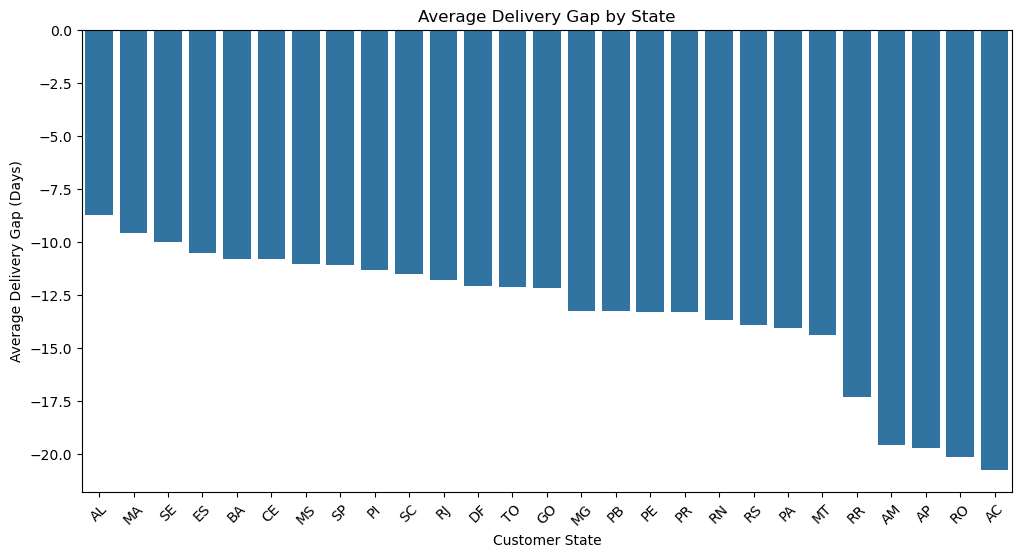

In [86]:
# Visualization
plt.figure(figsize=(12, 6))

sns.barplot(
    x=state_delay.index,
    y=state_delay.values
)

plt.title('Average Delivery Gap by State')
plt.xlabel('Customer State')
plt.ylabel('Average Delivery Gap (Days)')
plt.xticks(rotation=45)

plt.show()

## Q3.3 — Delivery Gap vs Review Score

Analyze the relationship between delivery gap and review scores to understand whether delivery performance is associated with customer satisfaction.

In [89]:
# Q3.3 — Delivery Gap vs Review Score


# Step 1: Select delivery information
delivery_review_df = state_delivery_df[
    [
        'order_id',
        'delivery_gap_days'
    ]
].copy()


# Step 2: Select review information
review_df = reviews[
    [
        'order_id',
        'review_score'
    ]
].copy()


# Step 3: Merge delivery data with review data
delivery_review_df = delivery_review_df.merge(
    review_df,
    on='order_id',
    how='left'
)


# Step 4: Remove orders without a review score
delivery_review_df = delivery_review_df.dropna(
    subset=['review_score']
)


# Step 5: Average delivery gap by review score
review_delay = (
    delivery_review_df
    .groupby('review_score')['delivery_gap_days']
    .mean()
    .sort_index()
)

print(review_delay)


# Step 6: Calculate correlation
correlation = delivery_review_df[
    ['delivery_gap_days', 'review_score']
].corr().loc['delivery_gap_days', 'review_score']

print("Correlation between Delivery Gap and Review Score:", correlation)




review_score
1.0    -4.060580
2.0    -8.634818
3.0   -10.774052
4.0   -12.380840
5.0   -13.388153
Name: delivery_gap_days, dtype: float64
Correlation between Delivery Gap and Review Score: -0.266763661637995


### Delivery Gap vs Review Score

Visualize the relationship between delivery gap and review scores to identify whether delivery performance is associated with customer ratings.

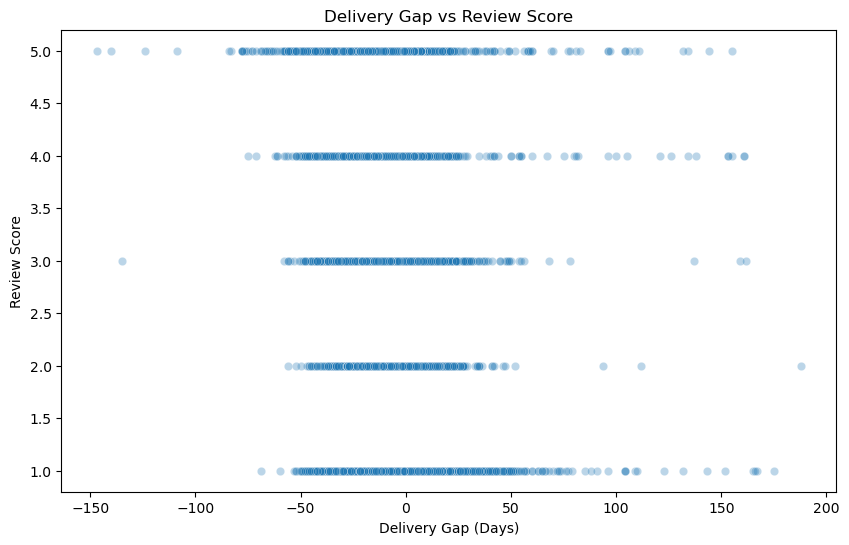

In [88]:
# Step 7: Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=delivery_review_df,
    x='delivery_gap_days',
    y='review_score',
    alpha=0.3
)

plt.title('Delivery Gap vs Review Score')
plt.xlabel('Delivery Gap (Days)')
plt.ylabel('Review Score')

plt.show()

# Module 4 — Pricing & Freight Analysis

## Q4.1 — Price vs Freight Correlation

Analyze the correlation between product price and freight value to understand whether higher-priced products tend to have higher shipping costs.

In [91]:
# Select required columns
price_freight_df = items[['price', 'freight_value']].copy()

# Rename columns for better readability
price_freight_df = price_freight_df.rename(columns={
    'price': 'Product Price',
    'freight_value': 'Freight Value'
})

# Check missing values
missing_values = price_freight_df.isnull().sum()

print("Missing Values:")
print(missing_values)

# Remove rows with missing values
price_freight_df = price_freight_df.dropna(
    subset=['Product Price', 'Freight Value']
)

# Calculate Pearson correlation
correlation = price_freight_df[
    ['Product Price', 'Freight Value']
].corr().loc[
    'Product Price', 'Freight Value'
]

print("Correlation between Product Price and Freight Value:", correlation)



Missing Values:
Product Price    0
Freight Value    0
dtype: int64
Correlation between Product Price and Freight Value: 0.4142043103630346


### Product Price vs Freight Value

Visualize the relationship between product price and freight value to identify the strength and direction of their linear relationship.

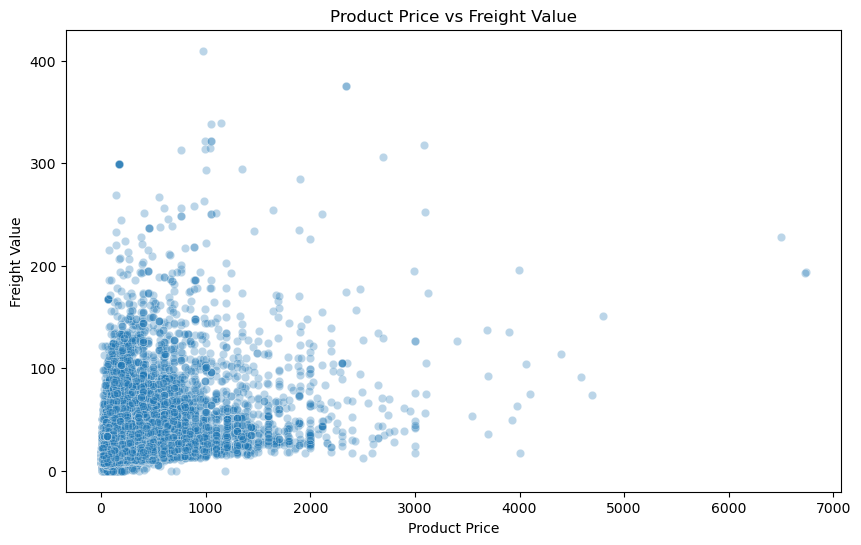

In [92]:
# Visualize the relationship
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_freight_df,
    x='Product Price',
    y='Freight Value',
    alpha=0.3
)

plt.title('Product Price vs Freight Value')
plt.xlabel('Product Price')
plt.ylabel('Freight Value')
plt.show()

## Q4.2 — Freight Burden vs Cancellation Rate

Analyze whether the proportion of shipping cost relative to product price is associated with differences in order cancellation rates.

In [95]:
# Select required columns from items
freight_df = items[
    ['order_id', 'price', 'freight_value']
].copy()

# Select required columns from orders
order_status_df = orders[
    ['order_id', 'order_status']
].copy()

# Merge item data with order status
freight_df = freight_df.merge(
    order_status_df,
    on='order_id',
    how='left'
)

# Check missing values
print("Missing Values:")
print(
    freight_df[
        ['price', 'freight_value', 'order_status']
    ].isnull().sum()
)

# Remove rows with missing values
freight_df = freight_df.dropna(
    subset=['price', 'freight_value', 'order_status']
)

# Keep only positive product prices
freight_df = freight_df[
    freight_df['price'] > 0
].copy()

# Calculate freight burden
freight_df['freight_burden'] = (
    freight_df['freight_value'] / freight_df['price']
)

# Divide freight burden into three groups
freight_df['freight_burden_group'] = pd.qcut(
    freight_df['freight_burden'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Create cancellation flag
freight_df['is_cancelled'] = (
    freight_df['order_status'] == 'canceled'
).astype(int)

# Calculate cancellation rate as percentage
cancellation_rate = (
    freight_df
    .groupby('freight_burden_group', observed=True)['is_cancelled']
    .mean()
    .mul(100)
)

print("Cancellation Rate by Freight Burden (%):")
print(cancellation_rate)



Missing Values:
price            0
freight_value    0
order_status     0
dtype: int64
Cancellation Rate by Freight Burden (%):
freight_burden_group
Low       0.617826
Medium    0.404794
High      0.420784
Name: is_cancelled, dtype: float64


### Cancellation Rate by Freight Burden

Visualize the cancellation rate across low, medium, and high freight burden groups to compare cancellation patterns between the three groups.

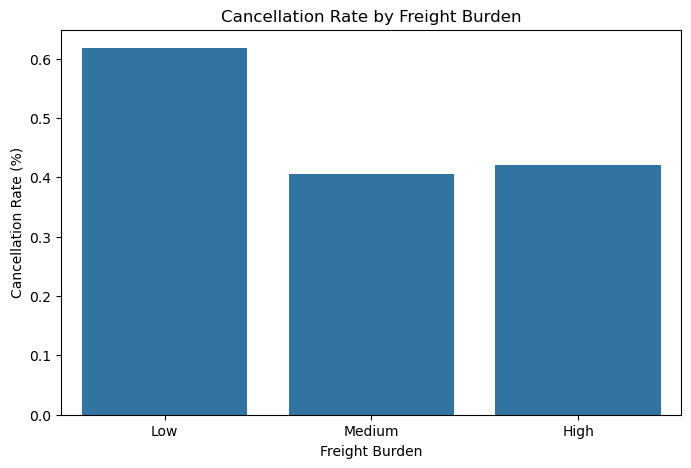

In [96]:
# Visualize cancellation rate
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cancellation_rate.index,
    y=cancellation_rate.values
)

plt.title('Cancellation Rate by Freight Burden')
plt.xlabel('Freight Burden')
plt.ylabel('Cancellation Rate (%)')
plt.show()

## Q4.3 — Price Tier vs Average Freight Value

Divide products into low, medium, and high price tiers and compare their average freight value to understand how shipping costs vary across product price levels.

In [99]:
# Select required columns
price_tier_df = items[
    ['price', 'freight_value']
].copy()

# Rename columns for readability
price_tier_df = price_tier_df.rename(columns={
    'price': 'Product Price',
    'freight_value': 'Freight Value'
})

# Check missing values
print("Missing Values:")
print(price_tier_df.isnull().sum())

# Remove rows with missing values
price_tier_df = price_tier_df.dropna(
    subset=['Product Price', 'Freight Value']
)

# Keep only positive product prices
price_tier_df = price_tier_df[
    price_tier_df['Product Price'] > 0
].copy()

# Divide products into three price tiers
price_tier_df['Price Tier'] = pd.qcut(
    price_tier_df['Product Price'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Calculate average freight value by price tier
avg_freight_by_tier = (
    price_tier_df
    .groupby('Price Tier', observed=True)['Freight Value']
    .mean()
)

print("Average Freight Value by Price Tier:")
print(avg_freight_by_tier)



Missing Values:
Product Price    0
Freight Value    0
dtype: int64
Average Freight Value by Price Tier:
Price Tier
Low       14.729739
Medium    18.008665
High      27.344542
Name: Freight Value, dtype: float64


### Average Freight Value by Price Tier

Visualize the average freight value across low, medium, and high price tiers to compare shipping costs across different product price levels.

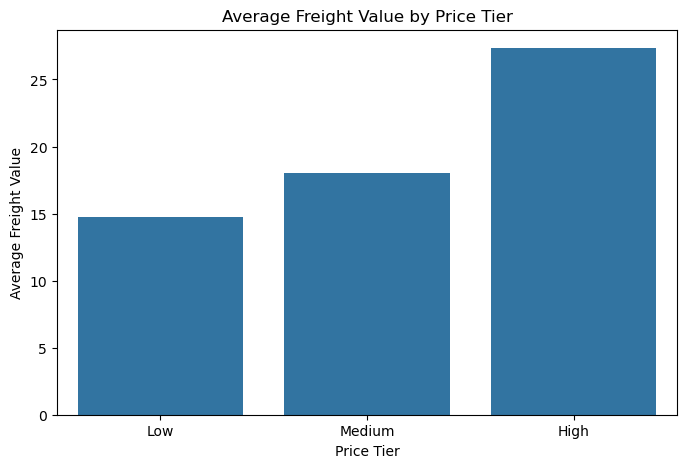

In [98]:
# Visualize average freight value
plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_freight_by_tier.index,
    y=avg_freight_by_tier.values
)

plt.title('Average Freight Value by Price Tier')
plt.xlabel('Price Tier')
plt.ylabel('Average Freight Value')
plt.show()